In [1]:
from dotenv import load_dotenv, find_dotenv
import rich
import os

# 自动向上查找 .env 文件
load_dotenv(find_dotenv())
modelName = os.getenv('OPENAI_MODEL')
print(modelName)


ModuleNotFoundError: No module named 'rich'

官网地址：
https://docs.langchain.com/oss/python/langgraph/streaming

# 一、流式中的不同模式


将以下一个或多个流模式作为列表传递给 stream 或 astream 方法
| 模式       | 描述                                                          |
| -------- | ----------------------------------------------------------- |
| values   | 在图的每一步之后流式传输状态的全部值。                                         |
| updates  | 在图的每一步之后流式传输状态的更新。如果在同一步骤中进行了多个更新（例如，运行了多个节点），则这些更新将分别流式传输。 |
| custom   | 从你的图节点内部流式传输自定义数据。                                          |
| messages | 从任何调用 LLM 的图节点流式传输 2 元组（LLM 令牌、元数据）。                        |
| debug    | 在整个图执行过程中尽可能流式传输信息。                                         |

LangGraph 的 stream_mode 参数让你选择性地获取图执行过程中的不同类型数据，支持单模式和多模式组合

# 二、基础使用

In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    topic: str
    joke: str

def refine_topic(state: State):
    return {"topic": state["topic"] + " and cats"}

def generate_joke(state: State):
    return {"joke": f"This is a joke about {state['topic']}"}

graph = (
    StateGraph(State)
    .add_node(refine_topic)
    .add_node(generate_joke)
    .add_edge(START, "refine_topic")
    .add_edge("refine_topic", "generate_joke")
    .add_edge("generate_joke", END)
    .compile()
)

for chunk in graph.stream(
    {"topic": "ice cream"},
    stream_mode="updates",
):
    print(chunk)

{'refine_topic': {'topic': 'ice cream and cats'}}
{'generate_joke': {'joke': 'This is a joke about ice cream and cats'}}


# 三、不同状态演示

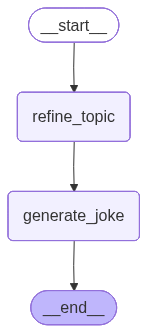

In [6]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END


class State(TypedDict):
  topic: str
  joke: str


def refine_topic(state: State):
    return {"topic": state["topic"] + " and cats","name":"wenwenc9"}


def generate_joke(state: State):
    return {"joke": f"This is a joke about {state['topic']}"}

graph = (
  StateGraph(State)
  .add_node(refine_topic)
  .add_node(generate_joke)
  .add_edge(START, "refine_topic")
  .add_edge("refine_topic", "generate_joke")
  .add_edge("generate_joke", END)
  .compile()
)
graph

## 1、updates更新
流式传输每一步节点返回的状态更新。
流式传输的输出包括节点的名称以及更新内容。
具体是每个节点为对象

In [7]:
for chunk in graph.stream(
    {"topic": "ice cream"},
    stream_mode="updates",
):
    for node, update in chunk.items():
        print(f"节点 {node} 更新: {update}")

节点 refine_topic 更新: {'topic': 'ice cream and cats'}
节点 generate_joke 更新: {'joke': 'This is a joke about ice cream and cats'}


In [9]:
for chunk in graph.stream(
    {"topic": "ice cream"},
    stream_mode=["updates"],
):
    print(chunk) # 返回的是元组，只要是列表的话

('updates', {'refine_topic': {'topic': 'ice cream and cats'}})
('updates', {'generate_joke': {'joke': 'This is a joke about ice cream and cats'}})


## 2、values值
使用此功能可以在每一步之后流式传输图的全状态。每个节点涉及到base_state 更新的都会打印出来

In [8]:
for chunk in graph.stream(
    {"topic": "ice cream"},
    stream_mode="values",
):
    print(chunk)

{'topic': 'ice cream'}
{'topic': 'ice cream and cats'}
{'topic': 'ice cream and cats', 'joke': 'This is a joke about ice cream and cats'}


## 3、custom
场景：工具执行进度、API 调用状态、用户友好的进度提示

配合get_stream_writer来使用

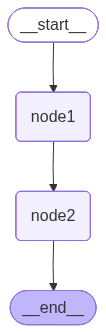

In [16]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.config import get_stream_writer
import time

class State(TypedDict):
    messages: list[str]

def node1(state: State):
    writer = get_stream_writer()
    writer("节点1: 开始处理...船期业务")      # 自定义流数据
    time.sleep(3) # 模拟业务耗时操作
    writer("节点1: 船期业务处理完成！")
    return {"messages": state["messages"] + ["节点1已处理"]}

def node2(state: State):
    writer = get_stream_writer()
    writer("节点2:生成回复中...")     # 自定义流数据
    return {"messages": state["messages"] + ["节点2已处理"]}

# 构建最小图
graph = (
    StateGraph(State)
    .add_node("node1", node1)
    .add_node("node2", node2)
    .add_edge(START, "node1")
    .add_edge("node1", "node2")
    .add_edge("node2", END)
    .compile()
)
graph

In [17]:
inputs = {"messages": ["你好世界"]}

# 同时流式传输更新和自定义数据
for chunk in graph.stream(inputs, stream_mode="custom"):
    # print(f"模式: {mode}")
    print(f"数据: {chunk}")
    print("---")

数据: 节点1: 开始处理...船期业务
---
数据: 节点1: 船期业务处理完成！
---
数据: 节点2:生成回复中...
---


In [18]:
inputs = {"messages": ["你好世界"]}

# 同时流式传输更新和自定义数据
for chunk in graph.stream(inputs, stream_mode=["updates","values","custom"]):
    # print(f"模式: {mode}")
    print(f"数据: {chunk}")
    print("---")

数据: ('values', {'messages': ['你好世界']})
---
数据: ('custom', '节点1: 开始处理...船期业务')
---
数据: ('custom', '节点1: 船期业务处理完成！')
---
数据: ('updates', {'node1': {'messages': ['你好世界', '节点1已处理']}})
---
数据: ('values', {'messages': ['你好世界', '节点1已处理']})
---
数据: ('custom', '节点2:生成回复中...')
---
数据: ('updates', {'node2': {'messages': ['你好世界', '节点1已处理', '节点2已处理']}})
---
数据: ('values', {'messages': ['你好世界', '节点1已处理', '节点2已处理']})
---


## 4、messages
场景：聊天界面，逐字显示 AI 回复
使用 messages 流模式，从您的任何部分（包括节点、工具、子图或任务）流式传输大型语言模型（LLM）输出字节串 。

In [24]:
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage
import time

class State(TypedDict):
    messages: Annotated[list, add_messages]

def node1(state: State):
    """节点1：模拟流式生成分析结果"""
    text = "正在分析船期查询...上海到洛杉矶航线分析完成！"

    # 关键：返回 AIMessage，LangGraph 会自动处理流式
    return {"messages": [AIMessage(content=text)]}

def node2(state: State):
    """节点2：模拟流式生成船期结果"""
    text = """
船期查询结果：
1. 马士基航运 - 1月20日开船
2. 中远海运 - 1月22日开船
3. 长荣海运 - 1月25日开船
查询完成！"""

    return {"messages": [AIMessage(content=text)]}

# 构建图
graph = (
    StateGraph(State)
    .add_node("analyze", node1)
    .add_node("query", node2)
    .add_edge(START, "analyze")
    .add_edge("analyze", "query")
    .add_edge("query", END)
    .compile()
)
inputs = {"messages": [HumanMessage(content="查询上海到洛杉矶船期")]}
current_node = None
for message, metadata in graph.stream(inputs, stream_mode="messages"):
    node_name = metadata.get("langgraph_node", "")
    # 节点切换时显示标题
    if node_name != current_node:
        if current_node:
            print("\n")
        print(f"[{node_name}] ", end="", flush=True)
        current_node = node_name
    # 逐字符模拟流式输出
    if hasattr(message, 'content') and message.content:
        for char in message.content:
            print(char, end="", flush=True)
            time.sleep(0.02)  # 控制输出速度



[analyze] 正在分析船期查询...上海到洛杉矶航线分析完成！

[query] 
船期查询结果：
1. 马士基航运 - 1月20日开船
2. 中远海运 - 1月22日开船
3. 长荣海运 - 1月25日开船
查询完成！

## 5、debug 开发者调试

In [30]:
import json
for chunk in graph.stream(inputs, stream_mode="debug"):
    print("★",chunk)
    print("\n")

★ {'step': 1, 'timestamp': '2026-01-15T07:46:13.367678+00:00', 'type': 'task', 'payload': {'id': '772925ec-1e15-40af-4ebe-c0d80d5d4402', 'name': 'analyze', 'input': {'messages': [HumanMessage(content='查询上海到洛杉矶船期', additional_kwargs={}, response_metadata={}, id='aa6f7cfb-1b93-40e0-8625-2f8daf9987b3')]}, 'triggers': ('branch:to:analyze',)}}


★ {'step': 1, 'timestamp': '2026-01-15T07:46:13.368054+00:00', 'type': 'task_result', 'payload': {'id': '772925ec-1e15-40af-4ebe-c0d80d5d4402', 'name': 'analyze', 'error': None, 'result': {'messages': [AIMessage(content='正在分析船期查询...上海到洛杉矶航线分析完成！', additional_kwargs={}, response_metadata={}, id='76fdb7dd-413d-4042-8def-00816ddcf9c0')]}, 'interrupts': []}}


★ {'step': 2, 'timestamp': '2026-01-15T07:46:13.368237+00:00', 'type': 'task', 'payload': {'id': '8649bf08-5034-a2ff-eac1-c7da22c03427', 'name': 'query', 'input': {'messages': [HumanMessage(content='查询上海到洛杉矶船期', additional_kwargs={}, response_metadata={}, id='aa6f7cfb-1b93-40e0-8625-2f8daf9987b3')

## 6、理解updates跟values差异


| 特性   | updates                          | values                          |
|--------|----------------------------------|---------------------------------|
| 含义   | 增量变化（这次改了啥）           | 完整状态（现在是啥样）          |
| 数据量 | 小（只包含变化的字段）           | 大（包含所有字段）              |
| 格式   | {节点名: {变化的字段}}           | {所有字段的当前值}              |
| 用途   | 追踪变化、日志记录               | 调试、状态监控                  |
| 类比   | 工人汇报“我做了什么”             | 拍全景照片“现在什么样”          |


In [4]:
from langgraph.graph import START, StateGraph
from typing import TypedDict

class HouseState(TypedDict):
    """房子的状态"""
    walls: str      # 墙壁
    floor: str      # 地板
    furniture: str  # 家具
    decoration: str # 装饰

def paint_walls(state: HouseState):
    """工人1：刷墙"""
    print("🎨 工人1正在刷墙...")
    return {"walls": "白色墙壁"}

def install_floor(state: HouseState):
    """工人2：铺地板"""
    print("🪵 工人2正在铺地板...")
    return {"floor": "木地板"}

def add_furniture(state: HouseState):
    """工人3：放家具"""
    print("🛋️ 工人3正在放家具...")
    return {"furniture": "沙发+桌子"}

def decorate(state: HouseState):
    """工人4：装饰"""
    print("🖼️ 工人4正在装饰...")
    return {"decoration": "挂画+绿植"}

# 构建装修流程
builder = StateGraph(HouseState)
builder.add_node("paint_walls", paint_walls)
builder.add_node("install_floor", install_floor)
builder.add_node("add_furniture", add_furniture)
builder.add_node("decorate", decorate)

builder.add_edge(START, "paint_walls")
builder.add_edge("paint_walls", "install_floor")
builder.add_edge("install_floor", "add_furniture")
builder.add_edge("add_furniture", "decorate")

graph = builder.compile()


In [5]:
print("=" * 60)
print("📋 模式1：updates（增量日志）")
print("=" * 60)

initial_state = {
    "walls": "",
    "floor": "",
    "furniture": "",
    "decoration": ""
}

for chunk in graph.stream(initial_state, stream_mode="updates"):
    print(f"📢 汇报: {chunk}")
    print("-" * 60)


📋 模式1：updates（增量日志）
🎨 工人1正在刷墙...
📢 汇报: {'paint_walls': {'walls': '白色墙壁'}}
------------------------------------------------------------
🪵 工人2正在铺地板...
📢 汇报: {'install_floor': {'floor': '木地板'}}
------------------------------------------------------------
🛋️ 工人3正在放家具...
📢 汇报: {'add_furniture': {'furniture': '沙发+桌子'}}
------------------------------------------------------------
🖼️ 工人4正在装饰...
📢 汇报: {'decorate': {'decoration': '挂画+绿植'}}
------------------------------------------------------------


In [6]:
print("=" * 60)
print("📸 模式2：values（完整快照）")
print("=" * 60)

for chunk in graph.stream(initial_state, stream_mode="values"):
    print(f"📸 当前房子状态:")
    print(f"   墙壁: {chunk.get('walls', '未完成')}")
    print(f"   地板: {chunk.get('floor', '未完成')}")
    print(f"   家具: {chunk.get('furniture', '未完成')}")
    print(f"   装饰: {chunk.get('decoration', '未完成')}")
    print("-" * 60)


📸 模式2：values（完整快照）
📸 当前房子状态:
   墙壁: 
   地板: 
   家具: 
   装饰: 
------------------------------------------------------------
🎨 工人1正在刷墙...
📸 当前房子状态:
   墙壁: 白色墙壁
   地板: 
   家具: 
   装饰: 
------------------------------------------------------------
🪵 工人2正在铺地板...
📸 当前房子状态:
   墙壁: 白色墙壁
   地板: 木地板
   家具: 
   装饰: 
------------------------------------------------------------
🛋️ 工人3正在放家具...
📸 当前房子状态:
   墙壁: 白色墙壁
   地板: 木地板
   家具: 沙发+桌子
   装饰: 
------------------------------------------------------------
🖼️ 工人4正在装饰...
📸 当前房子状态:
   墙壁: 白色墙壁
   地板: 木地板
   家具: 沙发+桌子
   装饰: 挂画+绿植
------------------------------------------------------------


# 四、综合案例

## 1、案例一，假流式

实际上是在节点中，进行response = llm.invoke ，该方法为模型最后的回复，并非真正的流式
只不会在for chunk 的时候，判断了为messages，然后底层是自动会拆成字节

```
# LangGraph 内部伪代码
def _emit_message_events(node_output):
    if "messages" in node_output:
        for msg in node_output["messages"]:
            # 即使是完整消息，也会作为 "流事件" 发出
            yield ("messages", (msg, metadata))

```

In [ ]:
from typing import Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.config import get_stream_writer
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage
from dotenv import load_dotenv, find_dotenv
import os
import time
from typing import TypedDict
load_dotenv(find_dotenv())
modelName = os.getenv('OPENAI_MODEL')

class State(TypedDict):
    messages: Annotated[list, add_messages]
    progress: int

def search_tool(state: State):
    writer = get_stream_writer()
    writer("🔍 正在查询订单数据库...")
    writer("📦 找到用户订单 #12345")
    writer("✅ 查询完成")
    return {"progress": 50}

def generate_reply_llm(state: State):
    writer = get_stream_writer()
    writer("🤖 豆包 AI 正在生成个性化回复...")

    llm = ChatOpenAI(model=modelName)

    prompt = f"""
    用户查询订单状态，已查询到订单#12345
    当前进度: {state['progress']}%

    请生成简短友好的客服回复，中文输出。
    """
    # 返回 AIMessage 对象，而不是字符串
    response = llm.invoke(prompt)
    return {"messages": [response]}  # 注意：返回 AIMessage 对象

# 构建图
graph = (
    StateGraph(State)
    .add_node("search", search_tool)
    .add_node("reply", generate_reply_llm)
    .add_edge(START, "search")
    .add_edge("search", "reply")
    .add_edge("reply", END)
    .compile()
)
graph

In [3]:
start_time = time.time() # 开始时间

# 初始消息也要用 HumanMessage
inputs = {
    "messages": [HumanMessage(content="查询我的订单状态")],
    "progress": 0
}

print("🤖 豆包智能客服启动")
print(f"使用模型: {modelName}")
print("=" * 50)

for mode, chunk in graph.stream(inputs, stream_mode=["custom", "messages", "updates"]):
    if mode == "custom":
        print(f"mode:{mode} ， {chunk}")

    elif mode == "updates":
        if isinstance(chunk, dict):
            node_name, update = next(iter(chunk.items()))
            print(f"mode:{mode} ，节点 {node_name} 完成")

    elif mode == "messages":
        # 现在会有数据了！
        msg, metadata = chunk
        if hasattr(msg, 'content') and msg.content:
            print(f"mode:{mode} ， {msg.content}")
end_time = time.time() # 结束时间
print("\n" + "=" * 50)
print("🎉 豆包客服会话结束")
elapsed_time = end_time - start_time
print(f"函数耗时: {elapsed_time:.4f} 秒")

🤖 豆包智能客服启动
使用模型: doubao-1-5-pro-32k-250115
mode:custom ， 🔍 正在查询订单数据库...
mode:custom ， 📦 找到用户订单 #12345
mode:custom ， ✅ 查询完成
mode:updates ，节点 search 完成
mode:custom ， 🤖 豆包 AI 正在生成个性化回复...
mode:messages ， 您好
mode:messages ， ，
mode:messages ， 您
mode:messages ， 查询
mode:messages ， 的
mode:messages ， 订单
mode:messages ，  #
mode:messages ， 1
mode:messages ， 2
mode:messages ， 3
mode:messages ， 4
mode:messages ， 5
mode:messages ，  当前
mode:messages ， 进度
mode:messages ， 为
mode:messages ，  
mode:messages ， 5
mode:messages ， 0
mode:messages ， %
mode:messages ，  
mode:messages ， 哦
mode:messages ， ~
mode:messages ，  
mode:updates ，节点 reply 完成

🎉 豆包客服会话结束
函数耗时: 3.0713 秒


## 2、案例二，真流式

In [6]:
from typing import Annotated, Generator
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.config import get_stream_writer
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage
from dotenv import load_dotenv, find_dotenv
import os
from typing import TypedDict
import time
load_dotenv(find_dotenv())
modelName = os.getenv('OPENAI_MODEL')

class State(TypedDict):
    messages: Annotated[list, add_messages]
    progress: int

def search_tool(state: State):
    writer = get_stream_writer()
    writer("🔍 正在查询订单数据库...")
    writer("📦 找到用户订单 #12345")
    writer("✅ 查询完成")
    return {"progress": 50}

def generate_reply_llm(state: State) -> Generator:
    """🔑 真流式节点 - 使用生成器逐令牌输出"""
    writer = get_stream_writer()
    writer("🤖 豆包 AI 正在生成个性化回复...")

    # 🔑 启用流式输出
    llm = ChatOpenAI(model=modelName, streaming=True)

    prompt = f"""
    用户查询订单状态，已查询到订单#12345
    当前进度: {state['progress']}%

    请生成简短友好的客服回复，中文输出。
    """

    # 逐令牌
    full_content = ""
    for chunk in llm.stream(prompt):
        # 每个令牌都作为独立的 AIMessage 发出
        # 注意! 这个会影响sate messages 这个键，最后一次的输出
        # yield {"messages": [AIMessage(content=chunk.content)]}
        # writer({"messages": chunk}) # 走 custom 通道，实时推送
        full_content += chunk.content
    return {"messages": [AIMessage(content=full_content)]}


# 构建图
graph = (
    StateGraph(State)
    .add_node("search", search_tool)
    .add_node("reply", generate_reply_llm)  # 生成器节点
    .add_edge(START, "search")
    .add_edge("search", "reply")
    .add_edge("reply", END)
    .compile()
)

In [5]:
start_time = time.time() # 开始时间
inputs = {
    "messages": [HumanMessage(content="查询我的订单状态")],
    "progress": 0
}

print("🤖 豆包智能客服启动（真流式版本）")
print(f"使用模型: {modelName}")
print("=" * 50)

for mode, chunk in graph.stream(inputs, stream_mode=["custom", "messages", "updates"]):
    if mode == "custom":
        print(f"mode:{mode} ， {chunk}")

    elif mode == "updates":
        if isinstance(chunk, dict):
            node_name, update = next(iter(chunk.items()))
            print(f"mode:{mode} ，节点 {node_name} 完成")

    elif mode == "messages":
        # 🔑 现在会逐令牌输出（打字机效果）
        msg, metadata = chunk
        if hasattr(msg, 'content') and msg.content:
            print(msg.content, end="", flush=True)  # 不换行，逐字输出
end_time = time.time() # 结束时间
print("\n" + "=" * 50)
print("🎉 豆包客服会话结束")
elapsed_time = end_time - start_time
print(f"函数耗时: {elapsed_time:.4f} 秒")

🤖 豆包智能客服启动（真流式版本）
使用模型: doubao-1-5-pro-32k-250115
mode:custom ， 🔍 正在查询订单数据库...
mode:custom ， 📦 找到用户订单 #12345
mode:custom ， ✅ 查询完成
mode:updates ，节点 search 完成
mode:custom ， 🤖 豆包 AI 正在生成个性化回复...
mode:updates ，节点 reply 完成

🎉 豆包客服会话结束
函数耗时: 6.4342 秒


# 五、子图流式

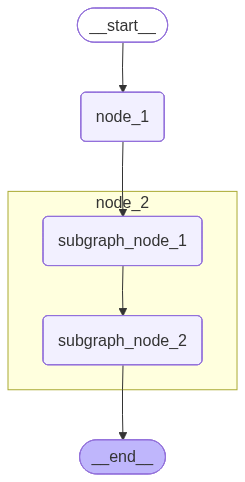

In [4]:
from langgraph.graph import START, StateGraph
from typing import TypedDict

# ==================== 定义子图 ====================
# 子图状态：定义子图内部节点之间传递的数据结构
class SubgraphState(TypedDict):
    foo: str  # 注意：这个键与父图状态共享（父图也有 foo 字段）
    bar: str  # 子图特有的字段（父图没有）

def subgraph_node_1(state: SubgraphState):
    """
    子图的第一个节点
    功能：初始化 bar 字段
    """
    print("  🔹 [子图节点1] 执行中...")
    return {"bar": "bar"}  # 向状态中添加 bar 字段

def subgraph_node_2(state: SubgraphState):
    """
    子图的第二个节点
    功能：将 foo 和 bar 拼接后更新 foo
    """
    print(f"  🔹 [子图节点2] 接收到状态: foo='{state['foo']}', bar='{state['bar']}'")
    return {"foo": state["foo"] + state["bar"]}  # 更新 foo 字段

# 构建子图
subgraph_builder = StateGraph(SubgraphState)
subgraph_builder.add_node(subgraph_node_1)
subgraph_builder.add_node(subgraph_node_2)
subgraph_builder.add_edge(START, "subgraph_node_1")  # 子图入口 → 节点1
subgraph_builder.add_edge("subgraph_node_1", "subgraph_node_2")  # 节点1 → 节点2
subgraph = subgraph_builder.compile()  # 编译子图

# ==================== 定义父图 ====================
# 父图状态：只包含 foo 字段
class ParentState(TypedDict):
    foo: str  # 父图的状态字段（会传递给子图）

def node_1(state: ParentState):
    """
    父图的节点1
    功能：在 foo 前面添加 "hi! " 前缀
    """
    print(f"🔷 [父图节点1] 接收到状态: foo='{state['foo']}'")
    return {"foo": "hi! " + state["foo"]}  # 更新 foo 字段

# 构建父图
builder = StateGraph(ParentState)
builder.add_node("node_1", node_1)  # 添加父图节点1
builder.add_node("node_2", subgraph)  # 🔑 添加子图作为节点（子图会被当作一个节点）
builder.add_edge(START, "node_1")  # 父图入口 → 节点1
builder.add_edge("node_1", "node_2")  # 节点1 → 子图节点
graph = builder.compile()  # 编译父图
from IPython.display import Image, display
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [7]:
# ==================== 流式执行 ====================
print("=" * 60)
print("🚀 开始流式执行父图（包含子图）")
print("=" * 60)

for chunk in graph.stream(
    {"foo": "foo"},  # 初始输入：foo="foo"
    stream_mode="updates",  # 流式模式：返回每个节点的状态更新
    subgraphs=True,  # 🔑 关键参数：设置为 True 以流式输出子图内部节点的执行结果
):
    print(chunk)
    print("-" * 60)

print("=" * 60)
print("✅ 执行完成")
print("=" * 60)

🚀 开始流式执行父图（包含子图）
🔷 [父图节点1] 接收到状态: foo='foo'
((), {'node_1': {'foo': 'hi! foo'}})
------------------------------------------------------------
  🔹 [子图节点1] 执行中...
  🔹 [子图节点2] 接收到状态: foo='hi! foo', bar='bar'
(('node_2:242604ba-21cf-59bf-44c0-dccc0b0fbe7d',), {'subgraph_node_1': {'bar': 'bar'}})
------------------------------------------------------------
(('node_2:242604ba-21cf-59bf-44c0-dccc0b0fbe7d',), {'subgraph_node_2': {'foo': 'hi! foobar'}})
------------------------------------------------------------
((), {'node_2': {'foo': 'hi! foobar'}})
------------------------------------------------------------
✅ 执行完成
